In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

First 5 rows:
   study_hours  attendance  assignment_score  test_score  sleep_hours  \
0         4.81       57.87             88.92       66.04         4.00   
1         1.58       68.39             76.97       62.98         5.98   
2         4.01       61.59             78.64       70.23         8.51   
3         1.00       50.00             79.11       54.96         4.00   
4         6.00       77.14             92.00       85.03         4.00   

   practice_score  passed  
0           93.96       1  
1           51.18       0  
2           37.61       0  
3           45.00       1  
4          100.00       1  

Dataset shape: (500, 7)

Class distribution:
passed
0    276
1    224
Name: count, dtype: int64

========== TEST METRICS ==========
Accuracy  : 0.7600
Precision : 0.7059
Recall    : 0.8000
F1 Score  : 0.7500
ROC-AUC   : 0.8638
Log Loss  : 0.4767
Brier Score: 0.1532

Confusion Matrix:
[[40 15]
 [ 9 36]]

Classification Report:
              precision    recall  f1-score   supp

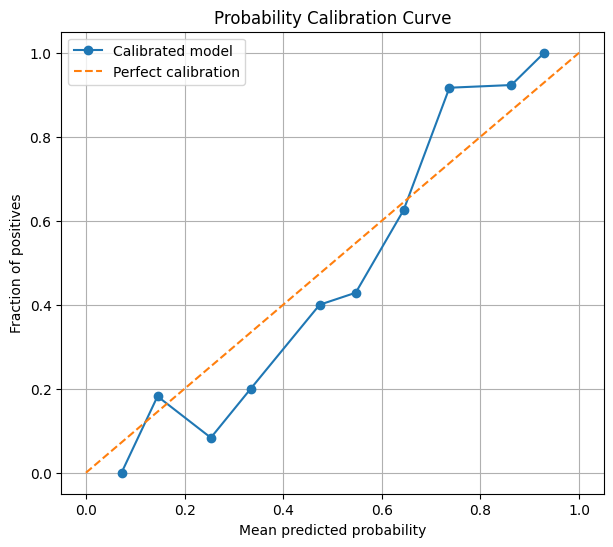


========== METRIC SUMMARY ==========
     Metric    Value
   Accuracy 0.760000
  Precision 0.705882
     Recall 0.800000
   F1 Score 0.750000
    ROC-AUC 0.863838
   Log Loss 0.476666
Brier Score 0.153217


In [5]:
# Cross-Validation, Metrics, and Calibration Project
# Machine Learning - Binary Classification

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab/ml_cross_validation_calibration_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nClass distribution:")
print(df["passed"].value_counts())

# Features and target
X = df.drop("passed", axis=1)
y = df["passed"]

# ---------------------------------------------------------
# 2. Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------------
# 3. Build Logistic Regression pipeline
# ---------------------------------------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 4. Classification Metrics
# ---------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print("\n========== TEST METRICS ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"Log Loss  : {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 5. 5-Fold Stratified Cross-Validation
# ---------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(
    model, X, y, cv=cv, scoring="accuracy"
)

cv_f1 = cross_val_score(
    model, X, y, cv=cv, scoring="f1"
)

cv_roc_auc = cross_val_score(
    model, X, y, cv=cv, scoring="roc_auc"
)

print("\n========== 5-FOLD CROSS-VALIDATION ==========")
print("Accuracy scores:", cv_accuracy)
print(f"Mean Accuracy : {cv_accuracy.mean():.4f}")
print(f"Std Accuracy  : {cv_accuracy.std():.4f}")

print("\nF1 scores:", cv_f1)
print(f"Mean F1       : {cv_f1.mean():.4f}")

print("\nROC-AUC scores:", cv_roc_auc)
print(f"Mean ROC-AUC  : {cv_roc_auc.mean():.4f}")

# ---------------------------------------------------------
# 6. Probability Calibration
# ---------------------------------------------------------
# CalibratedClassifierCV uses cross-validation internally
# to calibrate predicted probabilities.
calibrated_model = CalibratedClassifierCV(
    estimator=model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]
calibrated_pred = (calibrated_prob >= 0.5).astype(int)

calibrated_logloss = log_loss(y_test, calibrated_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

print("\n========== CALIBRATED MODEL ==========")
print(f"Calibrated Accuracy : {accuracy_score(y_test, calibrated_pred):.4f}")
print(f"Calibrated F1       : {f1_score(y_test, calibrated_pred):.4f}")
print(f"Calibrated ROC-AUC  : {roc_auc_score(y_test, calibrated_prob):.4f}")
print(f"Calibrated Log Loss : {calibrated_logloss:.4f}")
print(f"Calibrated Brier    : {calibrated_brier:.4f}")

# ---------------------------------------------------------
# 7. Calibration Curve
# ---------------------------------------------------------
prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Probability Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 8. Metric Summary
# ---------------------------------------------------------
summary = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1 Score",
        "ROC-AUC", "Log Loss", "Brier Score"
    ],
    "Value": [
        accuracy, precision, recall, f1,
        roc_auc, logloss, brier
    ]
})

print("\n========== METRIC SUMMARY ==========")
print(summary.to_string(index=False))